In [1]:
from SphereDetect import SphereDetect

#### Testing the load data module
works for raw images and for cellprofiler output (OBS: a lot of data is missing)

In [2]:
# Example usage: this also works

detector = SphereDetect()
detected_spheres = detector.run( 
        regex = r'([A-P]\d{1,2})_T0001F001L01A03Z(\d+)C03', 
        channel = 'SYTO',
        # image_path = '/mnt/external-images-pvc/spher-colo52-az/CellPainting_20241220clearedspheroidsBOMI_20241220_151510/AssayPlate_Corning_3830/', 
        image_path = '/home/jovyan/share/data/analyses/christa/SphereDetect/cp_output.parquet',
        z_info = 'Metadata_Plane',
        offset = -2,
        fmin = 250,
        downsample = 4,
        visualize = False,
)

detected_spheres.head()


                                             image_path Metadata_Well  \
2066  /mnt/external-images-pvc/spher-colo52-az/CellP...           B02   
9406  /mnt/external-images-pvc/spher-colo52-az/CellP...           B02   
5248  /mnt/external-images-pvc/spher-colo52-az/CellP...           B02   
6446  /mnt/external-images-pvc/spher-colo52-az/CellP...           B02   
7058  /mnt/external-images-pvc/spher-colo52-az/CellP...           B02   
...                                                 ...           ...   
3246  /mnt/external-images-pvc/spher-colo52-az/CellP...           H23   
8437  /mnt/external-images-pvc/spher-colo52-az/CellP...           H23   
1770  /mnt/external-images-pvc/spher-colo52-az/CellP...           H23   
6111  /mnt/external-images-pvc/spher-colo52-az/CellP...           H23   
4239  /mnt/external-images-pvc/spher-colo52-az/CellP...           H23   

      Metadata_Z  normalized_variance  delta_normalized_variance  \
2066           1           175.273737                  

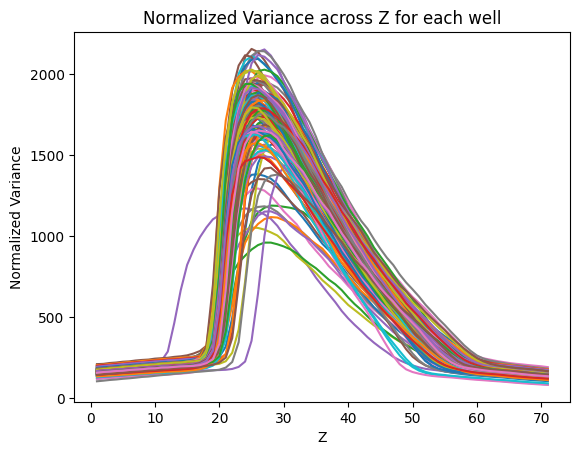

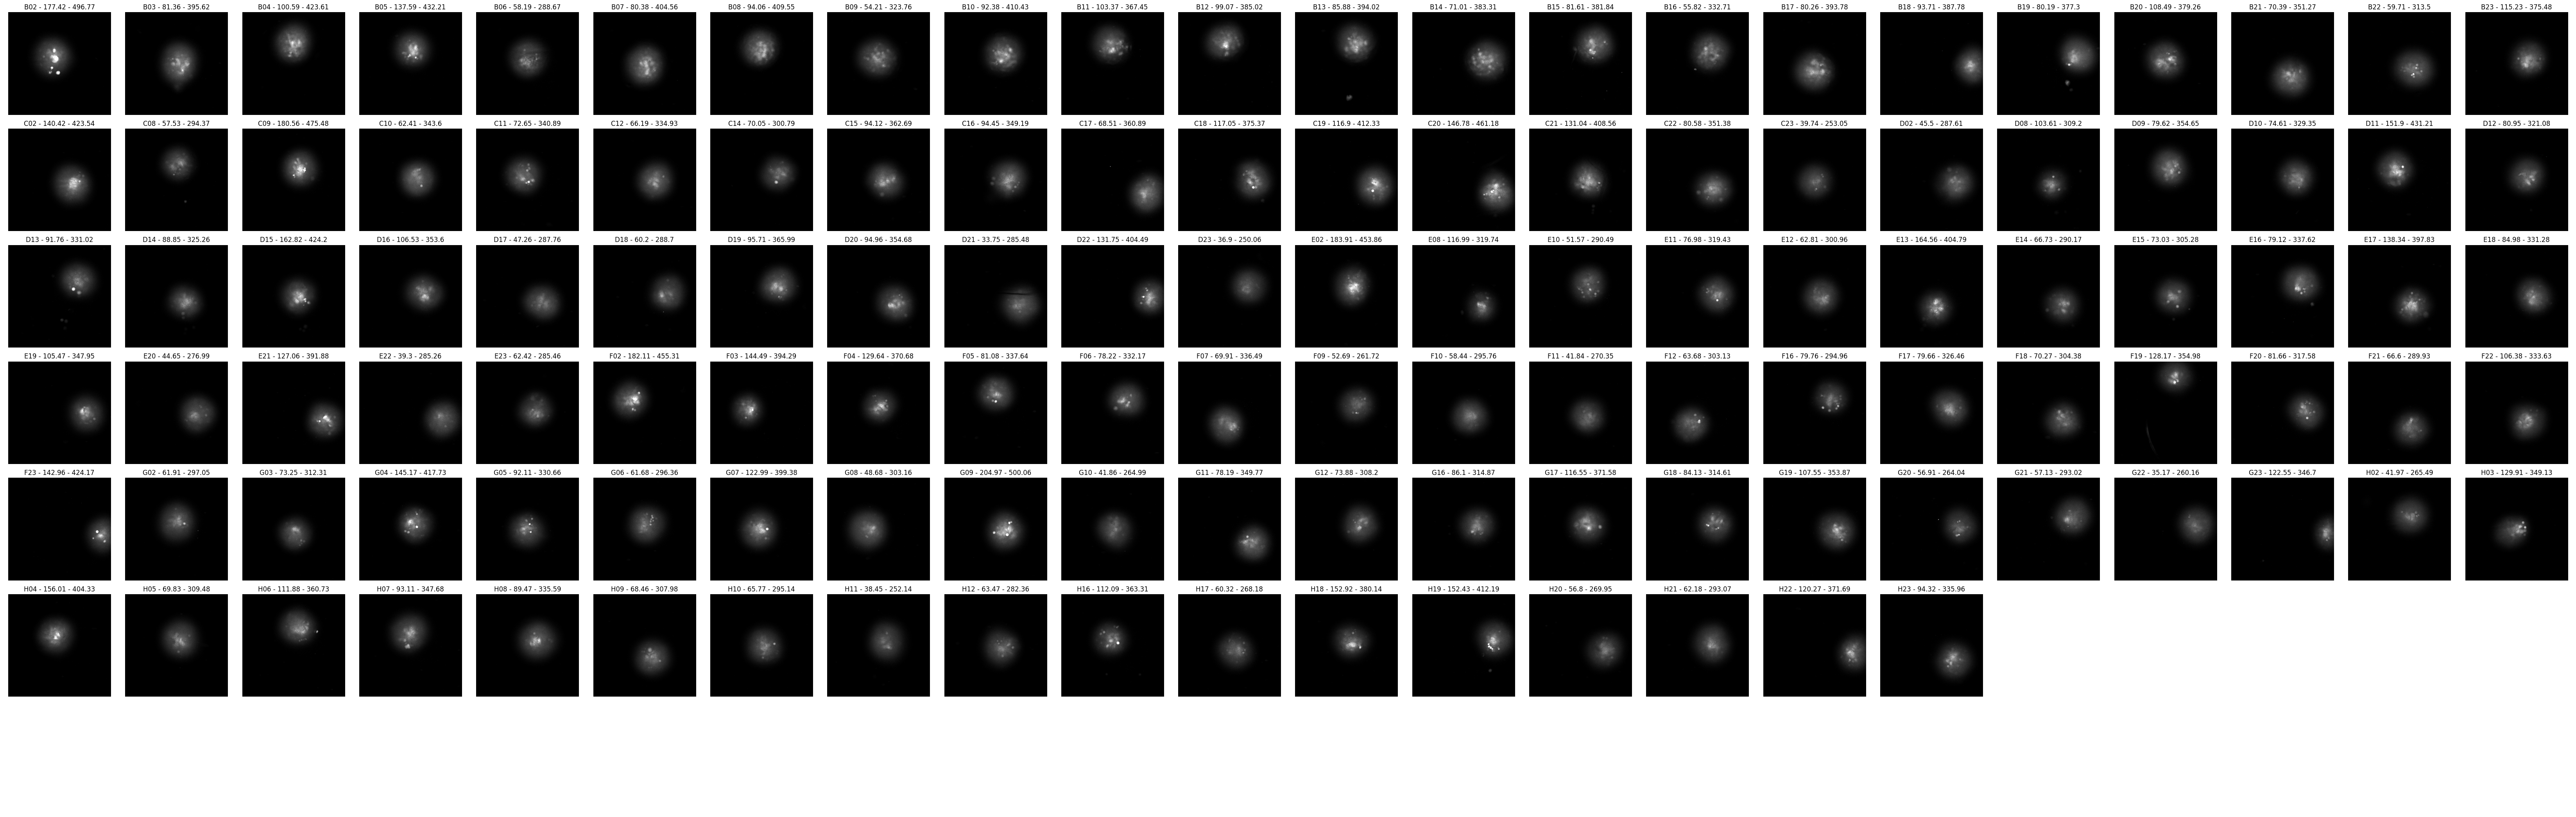

In [3]:
import matplotlib.pyplot as plt

### Plot the normalized variance across Z for each well        
df_plot = detected_spheres

# Group df by Metadata_Well and sort by Metadata_Z
df_grouped = df_plot.sort_values(by='Metadata_Z').groupby('Metadata_Well')

# Then plot the normalized variance across Z for each well
fig, ax = plt.subplots()
for name, group in df_grouped:
    ax.plot(group['Metadata_Z'], group['normalized_variance'], label=name)
ax.set_xlabel('Z')
ax.set_ylabel('Normalized Variance')
ax.set_title('Normalized Variance across Z for each well')

### Visualize the images
df_montage = detected_spheres

selected = df_montage.query('Metadata_Z_calculated == 0').sort_values(['Metadata_Well'])

images = []
labels = []  # e.g. Well numbers
img_data = None
for i, row in selected.iterrows():
    image_path = row['image_path']
    img_data = detector.read_image(image_path)
    images.append(img_data)
    
    # If your well information is in 'Metadata_Well', store it
    labels.append(str(row['Metadata_Well']) + ' - ' + str(round(row['delta_normalized_variance'],2)) + ' - ' + str(round(row['normalized_variance'],2)))

n_images = len(images)
n_cols = 22  
n_rows = 7  

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3 * n_cols, 3 * n_rows),  
    squeeze=False
)

for ax, img, label in zip(axes.flat, images, labels):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1500)
    ax.set_title(label)  
    ax.axis('off')
for ax in axes.flat[n_images:]:
    ax.axis('off')

plt.tight_layout()
plt.show()